# UMAP Projections for Subject Group .h5ad files

To enable visualization of our subject group .h5ad files in CELLxGENE, we'll add UMAP projections to these objects.

In [1]:
from datetime import date
import hisepy
import os
import pandas as pd
import polars as pl
import scanpy as sc
import scanpy.external as sce
import re

In [2]:
if not os.path.isdir('output'):
    os.mkdir('output')

## Helper functions

In [3]:
def find_stored_files(search_id, store = 'Service_Core'):
    ps_df = hisepy.list_files_in_project_store(store)
    ps_df = ps_df[['id', 'name']]
    search_df = ps_df[ps_df['name'].str.contains(search_id)]
    
    return search_df

In [4]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

In [5]:
def normalize_from_raw(adata):
    if adata.raw:
        adata = adata.raw.to_adata()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    return(adata)

In [6]:
def harmony_umap_pipeline(adata):
    print('Normalizing', end = '; ')
    adata = normalize_from_raw(adata)
    
    print('HVG', end = '; ')
    sc.pp.highly_variable_genes(adata)
    adata = adata[:, adata.var_names[adata.var['highly_variable']]].copy()
    print('Scaling', end = '; ')
    sc.pp.scale(adata)
    print('PCA', end = '; ')
    sc.tl.pca(
        adata, 
        svd_solver = 'arpack'
    )
    print('Harmony', end = '; ')
    sce.pp.harmony_integrate(
        adata, 
        'pool_id',
        max_iter_harmony = 10,
        verbose = False
    )
    print('Neighbors', end = '; ')
    sc.pp.neighbors(
        adata, 
        n_neighbors = 50,
        use_rep = 'X_pca_harmony', 
        n_pcs = 30
    )
    print('UMAP', end = '; ')
    sc.tl.umap(adata, random_state = 3030)
    
    return adata.obsm['X_umap'], adata.uns['umap']

In [7]:
def add_colorsets(adata, color_files):
    color_dicts = {}
    for level, file in color_files.items():
        color_df = pd.read_csv(file)

        color_dict = dict(zip(color_df[level], color_df[f'{level}_color']))
        color_dicts[level] = color_dict

    for level, color_dict in color_dicts.items():
        color_order = adata.obs[level].cat.categories
        level_colors = [color_dict[x] for x in color_order]
        adata.uns[f'{level}_colors'] = level_colors
        
    return adata

In [8]:
def inject_cat_obs(h5ad, obs_col, values):
    import h5py
    import numpy as np
    
    # Make a unique, sorted list of categories
    categories = list(set(values))
    categories.sort()
    # Make a list of category positions
    codes = []
    for value in values:
        codes.append(categories.index(value))
    # Convert to Numpy arrays for writing
    categories = np.array(categories)
    codes = np.array(codes, dtype = 'i8')

    # Open h5 file
    h5 = h5py.File(h5ad, 'r+')
    # Add column to column-order attribute of obs group
    co = h5['obs'].attrs['column-order']
    co = np.append(co, obs_col)
    h5['obs'].attrs['column-order'] = co
    
    # Create categories and codes for the target column
    h5.create_dataset(f'obs/{obs_col}/categories', (len(categories),), dtype=h5py.string_dtype())
    h5.create_dataset(f'obs/{obs_col}/codes', (len(codes),), dtype = 'i8')

    # Write categories and codes
    h5['obs'][obs_col]['categories'][:] = categories
    h5['obs'][obs_col]['codes'][:] = codes

    # Add column encoding attributes so anndata knows how to read the data
    h5['obs'][obs_col].attrs['encoding-type'] = 'categorical'
    h5['obs'][obs_col].attrs['encoding-version'] = '0.2.0'
    h5['obs'][obs_col].attrs['ordered'] = np.False_
    
    h5.close()

### Cell type colorsets

In [9]:
color_uuids = {
    'AIFI_L1': 'f06fcd94-834d-4490-b773-5cbb35760a51',
    'AIFI_L2': '36b6aa80-804e-4497-abe3-2d48e33bbdb5',
    'AIFI_L3': 'ee4b8ff6-3aa4-4bf0-841f-6d1b5fb284dd'
}

In [10]:
color_cache = {}
for name, uuid in color_uuids.items():
    color_cache[name] = hisepy.cache_files([uuid])[0]

### Sample Metadata

In [11]:
meta_uuid = 'af25e3e7-25c1-4476-afb4-926bd201db8f'

In [12]:
meta_file = hisepy.cache_files([meta_uuid])[0]

In [13]:
meta = pl.read_csv(meta_file)

In [14]:
meta.shape

(868, 19)

Add flu year, select kit and year to incorporate back into .h5ad files

In [15]:
meta = meta.with_columns(
    pl.when(pl.col('sample.drawDate') < '2020-07')
    .then(pl.lit('2019-2020'))
    .when(pl.col('sample.drawDate') < '2021-07')
    .then(pl.lit('2020-2021'))
    .otherwise(pl.lit('2021-2022'))
    .alias('vaccine.year')
).select(['sample.sampleKitGuid', 'vaccine.year']).unique()

In [16]:
vaccine_year_dict = dict(zip(meta['sample.sampleKitGuid'], meta['vaccine.year']))

## Find data in HISE

In [18]:
search_id = 'boron-potassium-aluminum'

In [19]:
search_df = find_stored_files(search_id, 'cohorts')

In [20]:
search_df

,id,name
17360,65b9c639-8bac-485d-9cdf-ec66acfd5869,boron-potassium-aluminum/SoundLife_YoungAdult_...
17361,5b7df27d-9957-4e3d-a054-328f2e224304,boron-potassium-aluminum/SoundLife_YoungAdult_...
17362,bc012978-7fa9-466e-9cac-f61fc67d9431,boron-potassium-aluminum/SoundLife_YoungAdult_...
17363,c2e6d243-8dd6-4e8b-9eda-62961896893e,boron-potassium-aluminum/SoundLife_YoungAdult_...
17364,5735fc28-f699-4d56-be49-4bb4bff39ed1,boron-potassium-aluminum/SoundLife_OlderAdult_...
17365,3b7c5d92-0a02-4acd-a743-a01f54cf5d6e,boron-potassium-aluminum/SoundLife_OlderAdult_...
17366,2e20043b-7e1a-4e33-88d8-50134db78ce6,boron-potassium-aluminum/SoundLife_OlderAdult_...
17367,4250a2b1-0eae-42c6-9cc6-5e6ebb83764d,boron-potassium-aluminum/SoundLife_OlderAdult_...


## Run UMAP and add cell type colorsets

In [21]:
out_files = []
for uuid in search_df['id']:
    h5ad = hisepy.cache_files([uuid])[0]
    bn = os.path.basename(h5ad)
    out_file = f'output/{bn}'

    if os.path.isfile(out_file):
        print(f'Previously processed {bn}. Skipping.')
    else:
        print(f'Starting {bn}')
        adata = sc.read_h5ad(h5ad)
        
        umap_res, umap_par = harmony_umap_pipeline(adata)
        adata.obsm['X_umap'] = umap_res
        adata.uns['umap'] = umap_par
    
        adata = add_colorsets(adata, color_cache)
    
        adata.write_h5ad(out_file)
        del(adata)
        
    out_files.append(out_file)

Previously processed SoundLife_YoungAdult_Female_CMVneg.h5ad. Skipping.
Previously processed SoundLife_YoungAdult_Female_CMVpos.h5ad. Skipping.
Previously processed SoundLife_YoungAdult_Male_CMVneg.h5ad. Skipping.
Previously processed SoundLife_YoungAdult_Male_CMVpos.h5ad. Skipping.
Previously processed SoundLife_OlderAdult_Female_CMVneg.h5ad. Skipping.
Previously processed SoundLife_OlderAdult_Female_CMVpos.h5ad. Skipping.
Previously processed SoundLife_OlderAdult_Male_CMVneg.h5ad. Skipping.
Previously processed SoundLife_OlderAdult_Male_CMVpos.h5ad. Skipping.


## Add vaccine.year
Could have done this along with the other updates, but forgot. We'll inject these directly into the .h5ad files so we don't have to copy the whole thing.

In [25]:
for out_file in out_files:
    adata = sc.read_h5ad(out_file, backed = 'r')
    vaccine_year = [vaccine_year_dict[k] for k in adata.obs['sample.sampleKitGuid']]
    del(adata)
    
    inject_cat_obs(out_file, 'vaccine.year', vaccine_year)

## Check UMAP projections
Let's make sure these look OK.

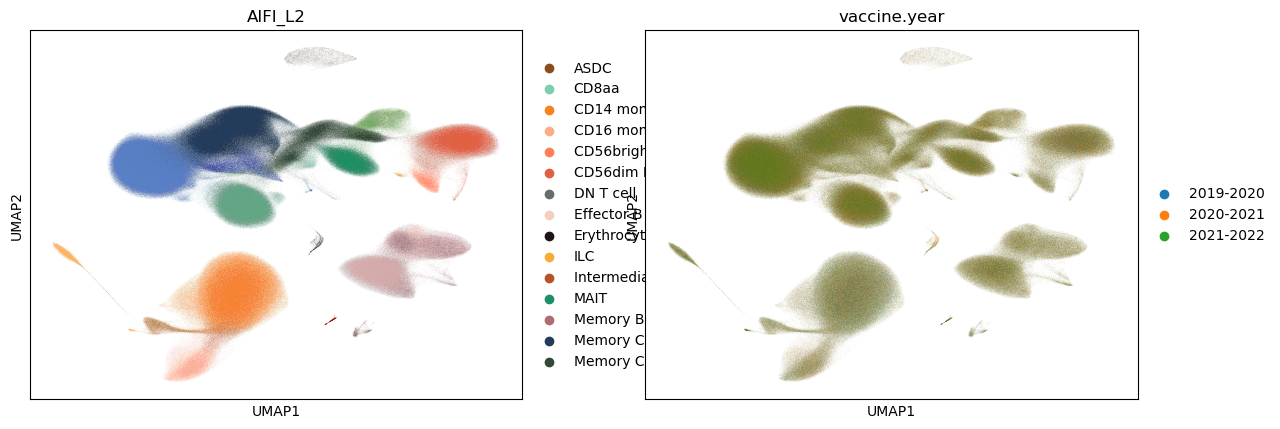

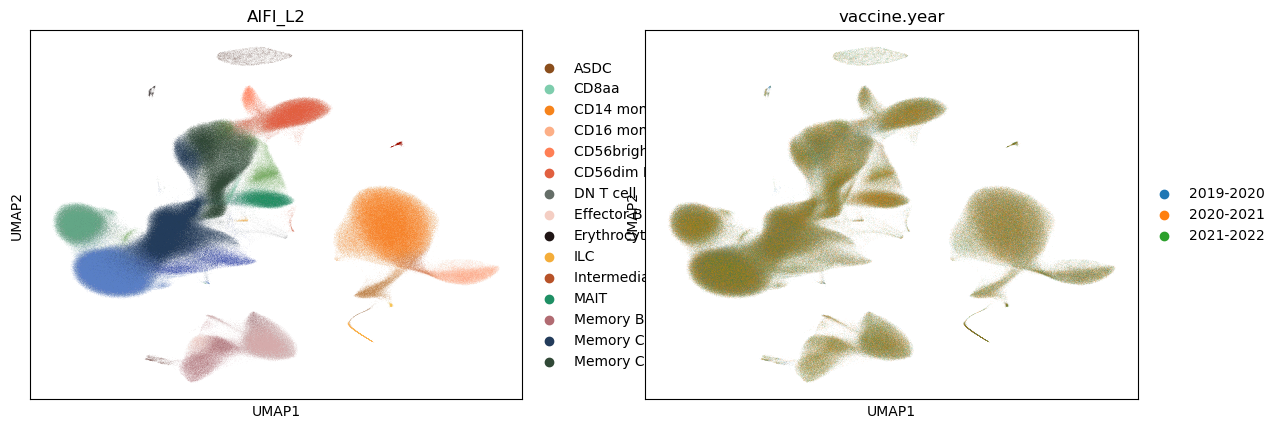

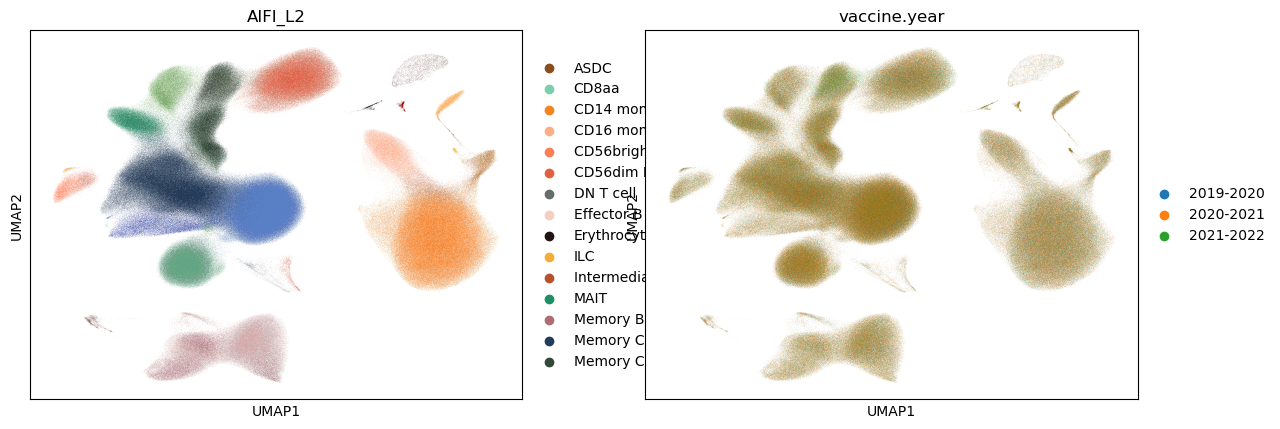

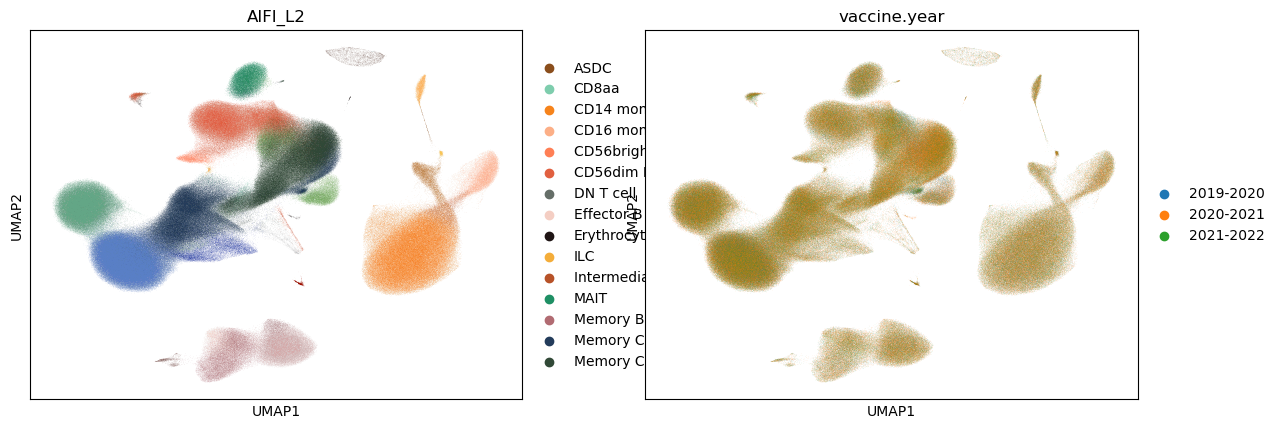

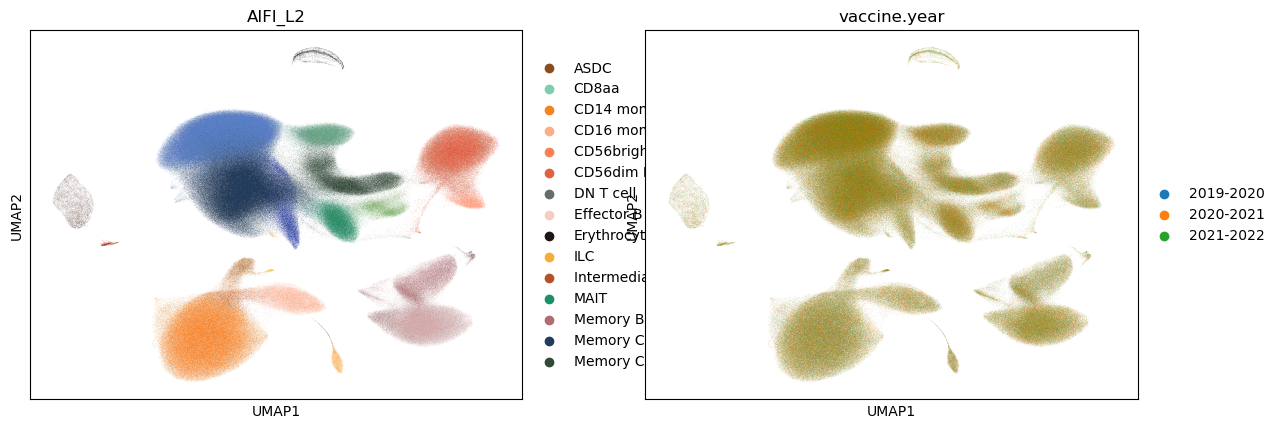

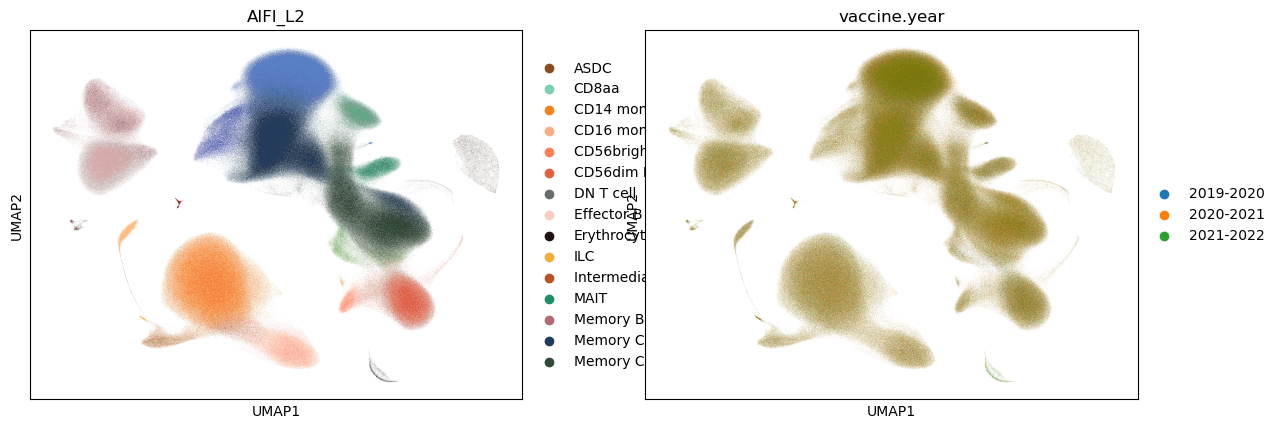

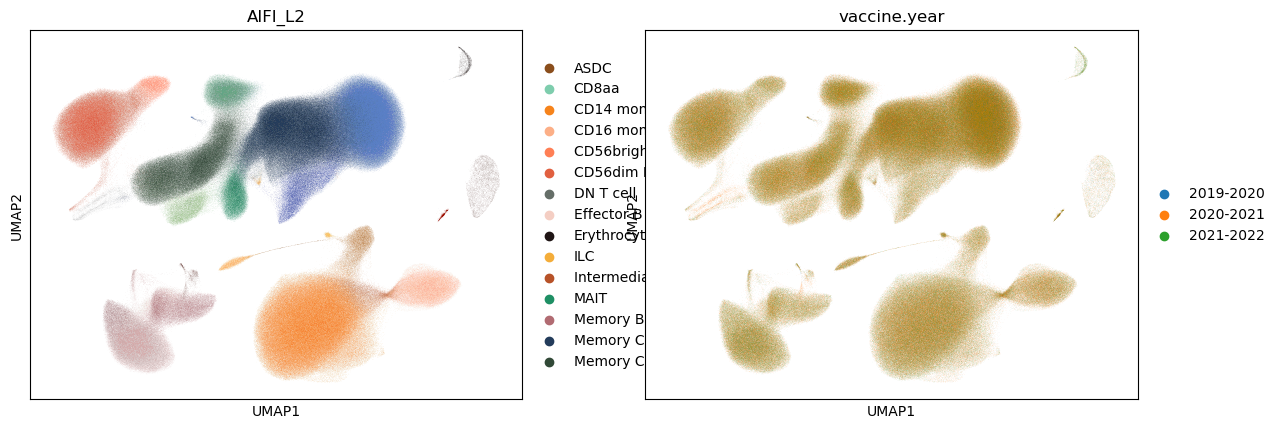

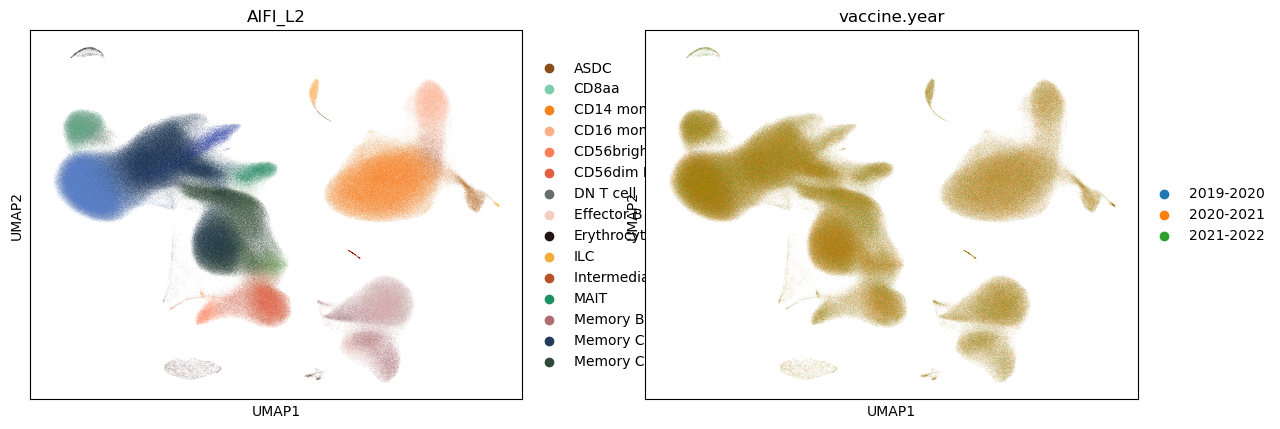

In [26]:
for out_file in out_files:
    adata = sc.read_h5ad(out_file, backed = 'r')
    sc.pl.umap(
        adata,
        color = ['AIFI_L2', 'vaccine.year']
    )
    del(adata)

## Upload data to HISE

Finally, we'll use `hisepy.upload.upload_files()` to send a copy of our output to HISE to use for distribution.

In [31]:
study_space_uuid = 'de025812-5e73-4b3c-9c3b-6d0eac412f2a'
title = 'DIHA Subject Group .h5ad with UMAP and vaccine.year {d}'.format(d = date.today())

In [32]:
search_id = element_id()
search_id

'barium-samarium-thallium'

In [27]:
in_files = search_df['id'].to_list()
in_files = in_files + [meta_uuid] + list(color_uuids.values())
in_files

['65b9c639-8bac-485d-9cdf-ec66acfd5869',
 '5b7df27d-9957-4e3d-a054-328f2e224304',
 'bc012978-7fa9-466e-9cac-f61fc67d9431',
 'c2e6d243-8dd6-4e8b-9eda-62961896893e',
 '5735fc28-f699-4d56-be49-4bb4bff39ed1',
 '3b7c5d92-0a02-4acd-a743-a01f54cf5d6e',
 '2e20043b-7e1a-4e33-88d8-50134db78ce6',
 '4250a2b1-0eae-42c6-9cc6-5e6ebb83764d',
 'af25e3e7-25c1-4476-afb4-926bd201db8f',
 'f06fcd94-834d-4490-b773-5cbb35760a51',
 '36b6aa80-804e-4497-abe3-2d48e33bbdb5',
 'ee4b8ff6-3aa4-4bf0-841f-6d1b5fb284dd']

In [28]:
out_files

['output/SoundLife_YoungAdult_Female_CMVneg.h5ad',
 'output/SoundLife_YoungAdult_Female_CMVpos.h5ad',
 'output/SoundLife_YoungAdult_Male_CMVneg.h5ad',
 'output/SoundLife_YoungAdult_Male_CMVpos.h5ad',
 'output/SoundLife_OlderAdult_Female_CMVneg.h5ad',
 'output/SoundLife_OlderAdult_Female_CMVpos.h5ad',
 'output/SoundLife_OlderAdult_Male_CMVneg.h5ad',
 'output/SoundLife_OlderAdult_Male_CMVpos.h5ad']

In [29]:
len(out_files)

8

In [33]:
hisepy.upload.upload_files(
    files = out_files,
    study_space_id = study_space_uuid,
    title = title,
    input_file_ids = in_files,
    destination = search_id
)

checking if conda environment can compile...


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': '439f0c88-d9ca-439a-9bb7-2acc28ae92c2',
 'ProcessId': 'c377eaea-9608-49ab-9735-bb5f6e00eb45',
 'WorkflowId': 'f0dd54ef-4a2f-453e-b3fe-e959f23327af',
 'FileIds': ['bdf86b7b-da55-42cb-8a9a-2f1ff29723ad',
  '32e96ab1-29af-4373-93d8-6824ed8de11e',
  '7e6130fd-1a70-4fc4-9c34-162b85fe3018',
  '047f7094-5b68-4f72-8e98-1f9e878f9ea3',
  '0d0273de-bebc-4652-b97b-53b0f470f8d3',
  '9e41c22f-561a-4a3b-89c5-1f94d1c268a0',
  'bde6ec90-eb77-4d31-bcea-aa78cd1f257f',
  '12d35e6e-50f1-4766-89c2-66c4f7d3951f']}

In [34]:
import session_info
session_info.show()